# Time Series



**Core reference:** Shmueli et al., *Data Mining for Business Analytics*, Chapter 16, 17, 18.  
**Case:** Airline passenger-demand forecasting  
**Dataset:** Classic monthly international airline-passenger series, 1949–1960 (`AirPassengers`)  
**Forecast horizon:** 12 months

---

# The Case

You are part of the analytics team at **AeroVista**, an international airline.

Senior management is preparing next year's operating plan. They need to decide:

- how much seat capacity to schedule,
- when seasonal peaks are likely to occur,
- whether demand is still growing,
- how much confidence to place in a forecast,
- and whether a sophisticated model actually adds value over a simple benchmark.

Management gives you a monthly passenger-demand history and asks:

> **“How many passengers should we expect next year?”**

Lets try to answer that question responsibly.

# The Research-Question Journey — An investigation

1. [RQ0 — What decision are we supporting?](#scrollTo=a564657f)
2. [RQ1 — What does the demand history look like?](#scrollTo=c3b44be4)
3. [RQ2 — Which time-series components are present?](#scrollTo=0a3ea249)
4. [RQ3 — Is the seasonal pattern stable, or does it change as demand grows?](#scrollTo=1b0eae98)
5. [RQ3B — Would changing the scale reveal a simpler pattern?](#scrollTo=765fcb3f)
6. [RQ3C — Can we separate trend, seasonality, and irregular variation?](#scrollTo=5bf33d00)
7. [RQ4 — What exactly are we forecasting, and what information is available at prediction time?](#scrollTo=d043ec85)
8. [RQ5 — How should we evaluate a forecast honestly?](#scrollTo=cd259ace)
9. [RQ5B — How will we measure forecast quality?](#scrollTo=fd300c17)
10. [RQ6 — Can a trivial forecast already perform well?](#scrollTo=137acb02)
11. [RQ7 — Does seasonality justify a stronger benchmark?](#scrollTo=df92cd6d)
12. [RQ8 — Can trend + seasonal regression improve the forecast?](#scrollTo=a744de0d)
13. [RQ9 — Can an adaptive smoothing model do better?](#scrollTo=b8c5ee04)
14. [RQ10 — Which model would we recommend?](#scrollTo=0d09f293)
15. [RQ10B — Did the model leave obvious structure unexplained?](#scrollTo=72b3442e)
16. [RQ10C — Is there residual autocorrelation?](#scrollTo=82729a4c)
17. [RQ11 — We selected a method. How do we forecast the real future?](#scrollTo=66147730)
18. [RQ12 — What should management be told besides the forecast?](#scrollTo=df228dab)

> Management asked us for a number. Our job is to decide whether the data justify that number.

## Python Environment

In [1]:
import warnings
#warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse_
from sklearn.metrics import mean_absolute_error as mae_
from statsmodels.tsa.seasonal import seasonal_decompose as sead_
from statsmodels.tsa.holtwinters import ExponentialSmoothing as exps_
from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
print("Environment ready.")

Environment ready.


## Case File: AeroVista Passenger Demand

The data contain monthly international airline passenger counts, in thousands, from January 1949 through December 1960.

- The classic `AirPassengers` dataset is framed as AeroVista's capacity-planning problem.

In [2]:
AirPassengers = 'https://raw.githubusercontent.com/tec03/Datasets/refs/heads/main/datasets/AirPassengers.csv'

df = pd.read_csv(AirPassengers,
                 parse_dates=["date"]
                 )
df.set_index("date", inplace=True)
df.head()

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [3]:
df["year"] = df.index.year
df["month"] = df.index.month
df["month_name"] = df.index.strftime("%b") #%B March; %Y 1949; %m 03; %Y-%m 1949-03
df.head(2)

,value,year,month,month_name
date,,,,
1949-01-01,112,1949,1,Jan
1949-02-01,118,1949,2,Feb


In [4]:
df = df.rename(columns={"value": "passengers"})
df.head(2)

,passengers,year,month,month_name
date,,,,
1949-01-01,112,1949,1,Jan
1949-02-01,118,1949,2,Feb


## [RQ0 — What decision are we supporting?](#scrollTo=8012e65e)




Management says: **“Forecast next year's passengers.”**

Translate that into a data-science problem before modeling.

<details><summary>Workspace</summary>


- Target: monthly passenger demand
- Granularity: monthly
- Horizon: 12 months
- Users: operations, finance, scheduling, capacity planning
- Decisions: capacity, staffing, budgeting, fleet/network planning
- Forecast error has operational consequences.

</detail>


## [RQ1 — What does the demand history look like?](#scrollTo=8012e65e)



Before fitting any model, **plot the data first**.

A time-series plot is our first diagnostic tool. It allows us to look for structure that may influence the forecasting strategy.

As you inspect the plot, do not ask only:

> “Is demand going up or down?”

Instead, look for several possible features:

- **Level** — what is the typical magnitude of passenger demand?
- **Trend** — is demand increasing, decreasing, or roughly stable over time?
- **Seasonality** — do similar patterns repeat at regular intervals?
- **Changing seasonal amplitude** — do the seasonal peaks and troughs become larger as the level increases?
- **Unusual observations** — are there months that look inconsistent with the surrounding pattern?
- **Changes in variability** — does the series become more volatile over time?

Observation task: Before discussing any model, write at least **five observations** from the graph.

1.  
2.  
3.  
4.  
5.  

Do not explain *why* the pattern occurs yet. First describe what the data show.

In [5]:
plt.style.use("ggplot")

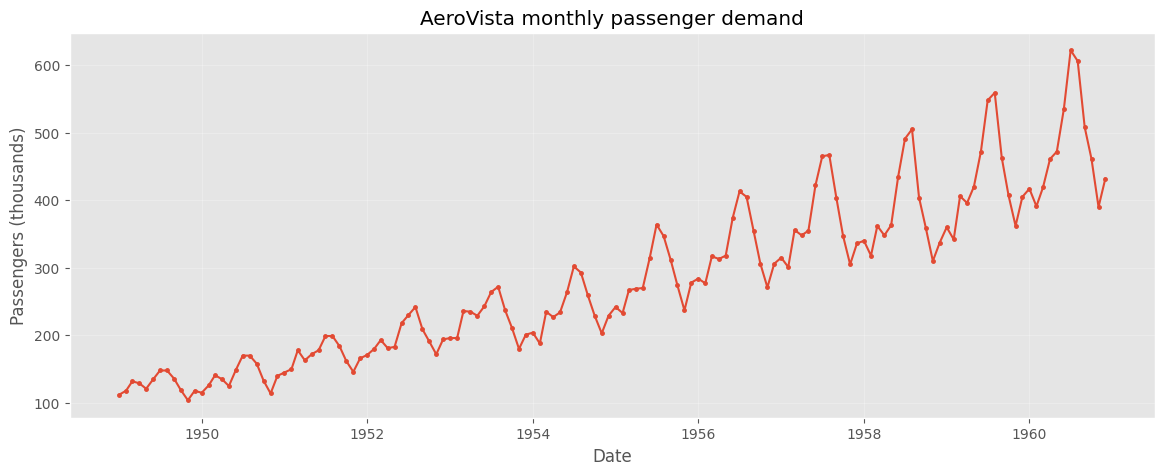

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df.index,          # x-axis: dates
    df["passengers"],  # y-axis: passenger values
    marker="o",
    markersize=2.5
)

ax.set_title("AeroVista monthly passenger demand")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers (thousands)")

ax.grid(alpha=0.25)
plt.show()

<details><summary><strong>Insights</strong></summary>

1. There is a clear upward trend in passenger demand over time.

2. A recurring annual pattern appears to be present, with similar peaks and troughs repeating each year.

3. The size of the seasonal fluctuations increases as the overall passenger level increases.

4. The variability of the series appears larger in later years than in earlier years.

5. The changing level and changing variability suggest that the series may not be stationary and that a transformation, such as a logarithm, could be useful.

</details>

## [RQ2 — Which time-series components are present?](#scrollTo=8012e65e)



Time series around four core components.

1. **Level** — typical magnitude (the typical value of the series around a particular time.)
2. **Trend** — long-run movement (the direction and rate at which that level changes over time.)
3. **Seasonality** — regular repeated pattern
4. **Noise** — irregular variation

###  classification

| Component       | Present? | Evidence                                                                                                                                    |
| --------------- | -------- | ------------------------------------------------------------------------------------------------------------------------------------------- |
| **Level**       | Yes      | Passenger demand has a typical magnitude that rises over time; early values are around 100–150 thousand while later values are much higher. |
| **Trend**       | Yes      | There is a clear long-term upward movement in passenger demand across the years.                                                            |
| **Seasonality** | Yes      | Peaks and troughs repeat at approximately the same months each year, indicating annual seasonality with period 12.                          |
| **Noise**       | Yes      | Individual monthly observations deviate from the underlying trend and seasonal pattern, showing irregular variation.                        |


<details><summary><strong>Note: seasonality</strong></summary>

Seasonality does not mean only winter/spring/summer/fall.

It means regular repeated temporal structure.

Ask:

- monthly data with annual pattern → period? **12**
- daily restaurant data with weekly pattern → period? **7**

</details>

## [RQ3 — Is the seasonal pattern stable, or does it change as demand grows?](#scrollTo=8012e65e)

In [7]:
df.month_name.unique()

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'], dtype=object)

In [8]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct", "Nov","Dec"]

In [9]:
df.head(3)

,passengers,year,month,month_name
date,,,,
1949-01-01,112,1949,1,Jan
1949-02-01,118,1949,2,Feb
1949-03-01,132,1949,3,Mar


In [10]:
monthly_profile = pd.pivot_table(df,
               index = 'month_name',
               values = 'passengers',
               aggfunc = ['mean','min','max','std']
               ).reindex(month_order).round(2)
monthly_profile

,mean,min,max,std
,passengers,passengers,passengers,passengers
month_name,,,,
Jan,241.75,112,417,101.03
Feb,235.00,118,391,89.62
Mar,270.17,132,419,100.56
Apr,267.08,129,461,107.37
May,271.83,121,472,114.74
Jun,311.67,135,535,134.22
Jul,351.33,148,622,156.83
Aug,351.08,148,606,155.78


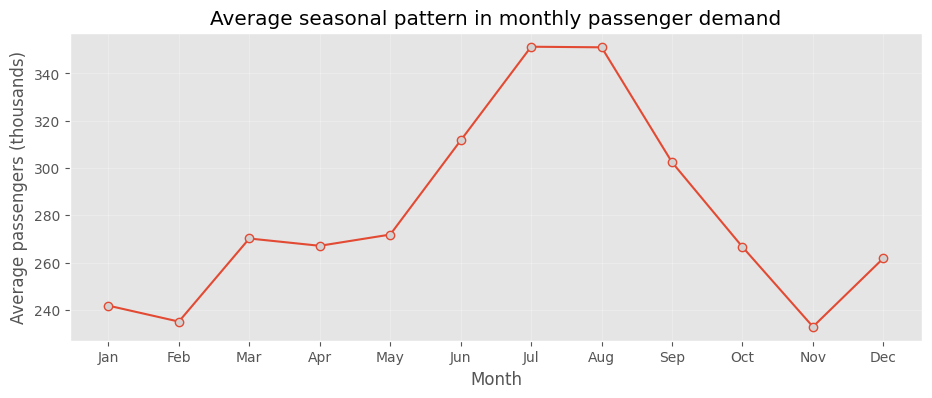

In [11]:
fig, ax = plt.subplots(figsize=(11,4))

ax.plot(monthly_profile.index,
        monthly_profile["mean"],
        marker="o",
        mfc='lightgray'
        )


ax.set_title("Average seasonal pattern in monthly passenger demand")
ax.set_xlabel("Month")
ax.set_ylabel("Average passengers (thousands)")
ax.grid(alpha=0.25)
plt.show()

<details><summary><strong>Insights</strong></summary>

1. Which months tend to be highest?
  > July and August show the highest average passenger demand.

2. Which months tend to be lowest?
  > November is the lowest month on average, with February also relatively low.

3. Why does this matter for capacity planning?
  > AeroVista should expect substantially higher demand during the summer peak and lower demand during the late-autumn/winter trough. This affects aircraft capacity, staffing, scheduling, pricing, and resource allocation.

4. Is the seasonal pattern equally strong every year, or does its magnitude appear to change as passenger demand grows?


The chart above shows the average seasonal pattern, but it does not tell us whether the seasonal swings stay the same size as demand grows. To check that, we compare years with different demand levels.

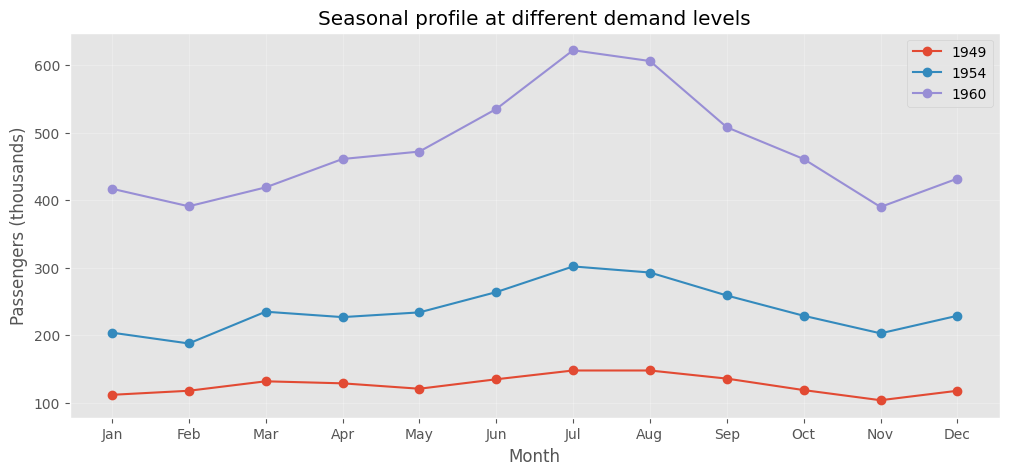

In [12]:
fig, ax = plt.subplots(figsize=(12,5))

for yr in [1949, 1954, 1960]:
    vals = df[df["year"] == yr]["passengers"].values
    ax.plot(month_order,
            vals,
            marker="o",
            label=str(yr)
            )

ax.set_title("Seasonal profile at different demand levels")
ax.set_ylabel("Passengers (thousands)")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

<details><summary>Insights</summary>

1. The shape of the seasonal pattern is similar across 1949, 1954, and 1960.
2. But the size of the seasonal swings becomes much larger as passenger demand grows.
3. In 1949, the difference between low and high months is relatively small.
4. By 1960, the peak-to-trough difference is much larger.
  > That is the key evidence for  multiplicative seasonality.

### Additive vs multiplicative seasonality


- Additive seasonality: the seasonal effect is roughly the same absolute size regardless of the level of the series.

- Multiplicative seasonality: the seasonal effect grows proportionally with the level.


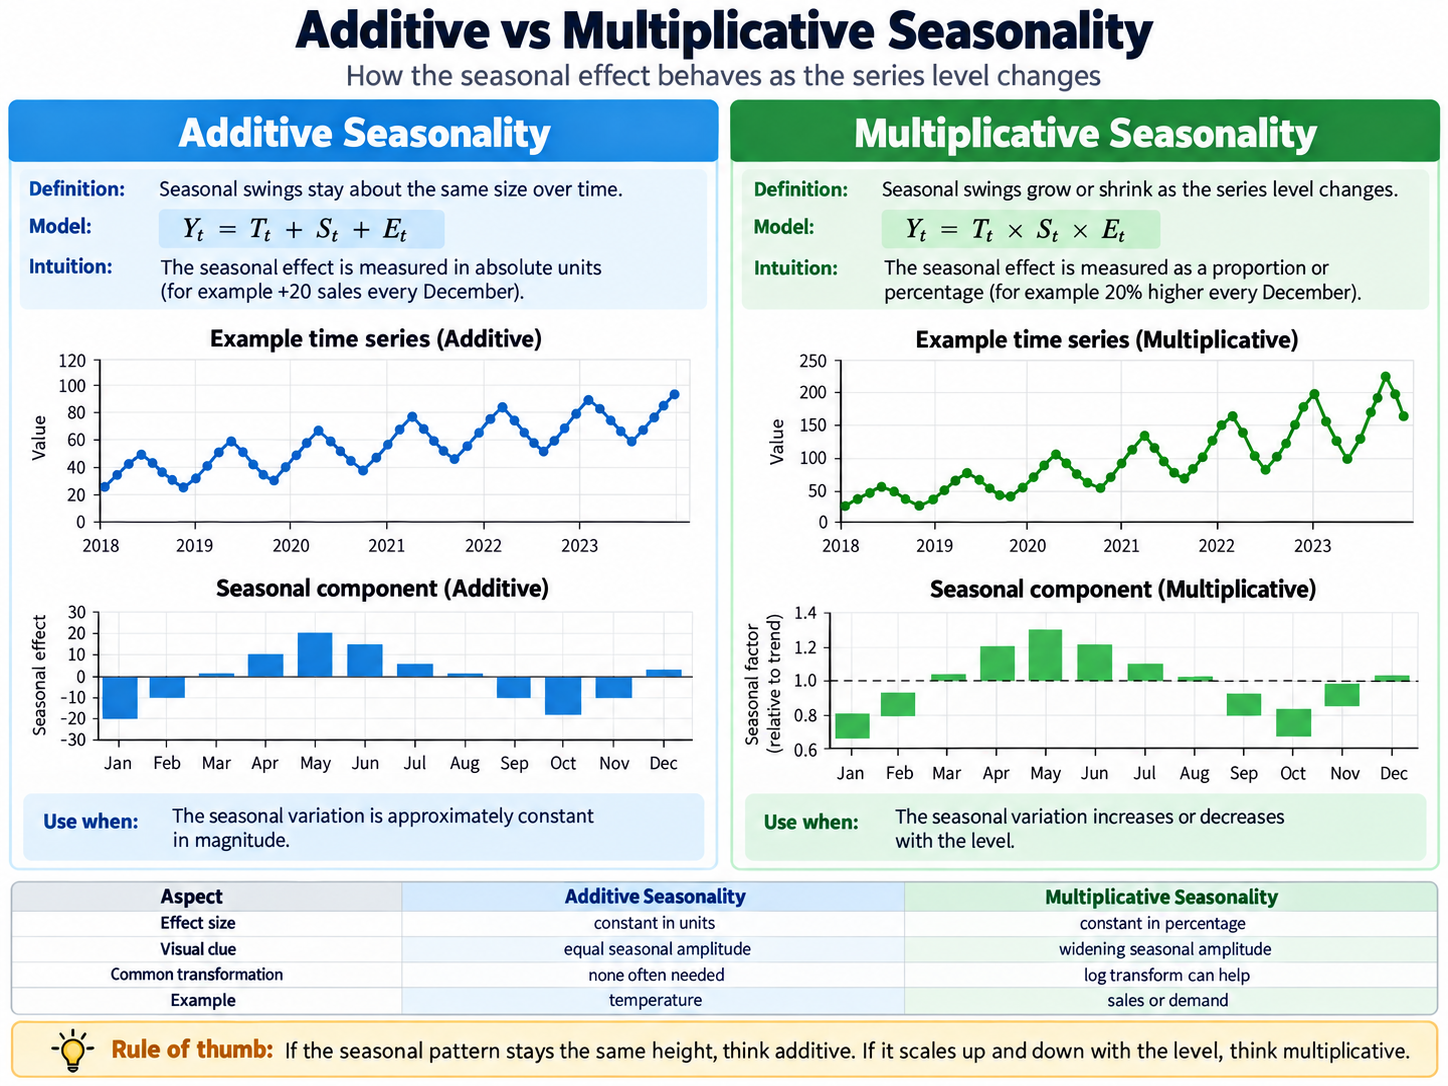

> Since the seasonal swings grow as passenger demand increases, the pattern appears multiplicative.

>> Can we change the scale so that those swings become more stable?

## [RQ3B — Would changing the scale reveal a simpler pattern?](#scrollTo=8012e65e)



A log transformation is often useful when variability grows with the level.

We do not log because a recipe says so; we log because the visual structure gives us a reason to investigate it.

>>> - Raw scale emphasizes absolute differences.
>>> - Log scale emphasizes relative or percentage differences.

The log transformation squeezes the `high values` more than the `low values`. Because the seasonal swings were getting larger as passenger demand grew, logging the series makes those swings more uniform.


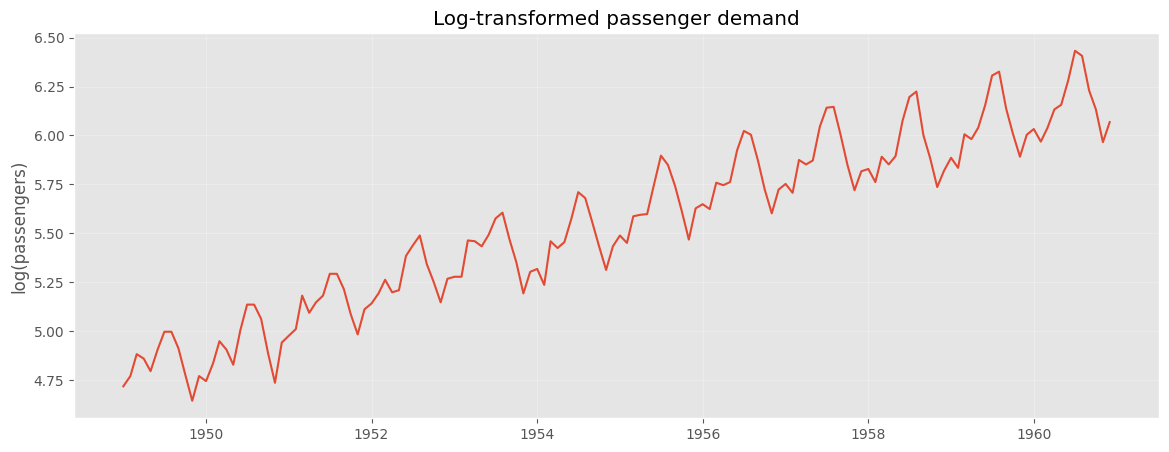

In [13]:
df["log_passengers"] = np.log(df["passengers"])

fig, ax = plt.subplots(figsize=(14,5))

ax.plot(df.index,
        df["log_passengers"]
        )

ax.set_title("Log-transformed passenger demand")
ax.set_ylabel("log(passengers)")
ax.grid(alpha=0.25)
plt.show()

<details><summary><strong>Insights</strong></summary>

- The seasonal pattern is still visible after the log transformation.
- The size of the seasonal swings is now more stable over time.
- The log scale compresses larger passenger values more than smaller ones.
- This reduces the increase in seasonal amplitude as demand grows.
- The transformed series therefore behaves more like an *additive seasonal process*.



> Key takeaway: The log transformation helps stabilize multiplicative seasonality.
</details>



| Transformation | Form | When it may help |
|---|---|---|
| **Log** | $\log(Y)$ | Variability grows strongly with the level; multiplicative behavior |
| **Square root** | $\sqrt{Y}$ | Variability increases with the level, but less dramatically; common with count data |
| **Box–Cox** | $Y^{(\lambda)}$ | Lets the data help choose an appropriate power transformation |
| **Yeo–Johnson** | Similar to Box–Cox | Useful when the data may contain zero or negative values |
| **No transformation** | $Y$ | Variability is already approximately constant |

The log transformation has made the seasonal variation more stable. Can we now separate the transformed series into its main components — trend, seasonality, and irregular variation — and examine each one individually?

## [RQ3C — Can we separate trend, seasonality, and irregular variation?](#scrollTo=8012e65e)



### Decomposition: separating the time series into parts

We can think of the passenger data as being made of three pieces:

` Observed passenger level = long-term trend + seasonal pattern + unexplained variation`

This is called *decomposition*.

After the log transformation, the seasonal swings became more stable. That means the transformed series can be treated approximately as:

$$
\log(Y_t)=T_t+S_t+R_t
$$

where:

- $T_t$ = long-term trend
- $S_t$ = seasonal effect
- $R_t$ = residual, or whatever is left unexplained

In simple words:

> What we observe each month = the general long-term movement + the usual seasonal effect + anything unusual that remains.

### Why do we decompose the log-transformed series?

The original passenger data showed **multiplicative-like seasonality**:

- when passenger demand was low, the seasonal swings were smaller;
- when passenger demand was high, the seasonal swings were larger.

After taking the log, those swings became more stable.

So instead of thinking about the data as:

$$
Y_t = Trend_t \times Seasonality_t \times Noise_t
$$

we can work on the log scale as:

$$
\log(Y_t)
=
\log(Trend_t)
+
\log(Seasonality_t)
+
\log(Noise_t)
$$

This makes an **additive decomposition** more appropriate.

#### What does `period` mean?

`period` tells the decomposition how many observations make up one complete seasonal cycle.

| Data frequency | Seasonal cycle | `period` |
|---|---|---:|
| Monthly | 1 year | 12 |
| Quarterly | 1 year | 4 |
| Daily | 1 week | 7 |
| Hourly | 1 day | 24 |

For our passenger data:

```
period = 12
```

because we have monthly data and the seasonal pattern repeats every year.

### What does the decomposition return?

```
decomp.observed  → the log-transformed passenger series
decomp.trend     → the long-term movement
decomp.seasonal  → the repeating seasonal pattern
decomp.resid     → what remains unexplained
```

A very simple way to remember it is:

> **Observed = Trend + Seasonality + Leftovers**

And the purpose is mainly to **understand the structure of the series**, not to forecast by itself.

In [14]:
df.head(2)

,passengers,year,month,month_name,log_passengers
date,,,,,
1949-01-01,112,1949,1,Jan,4.718499
1949-02-01,118,1949,2,Feb,4.770685


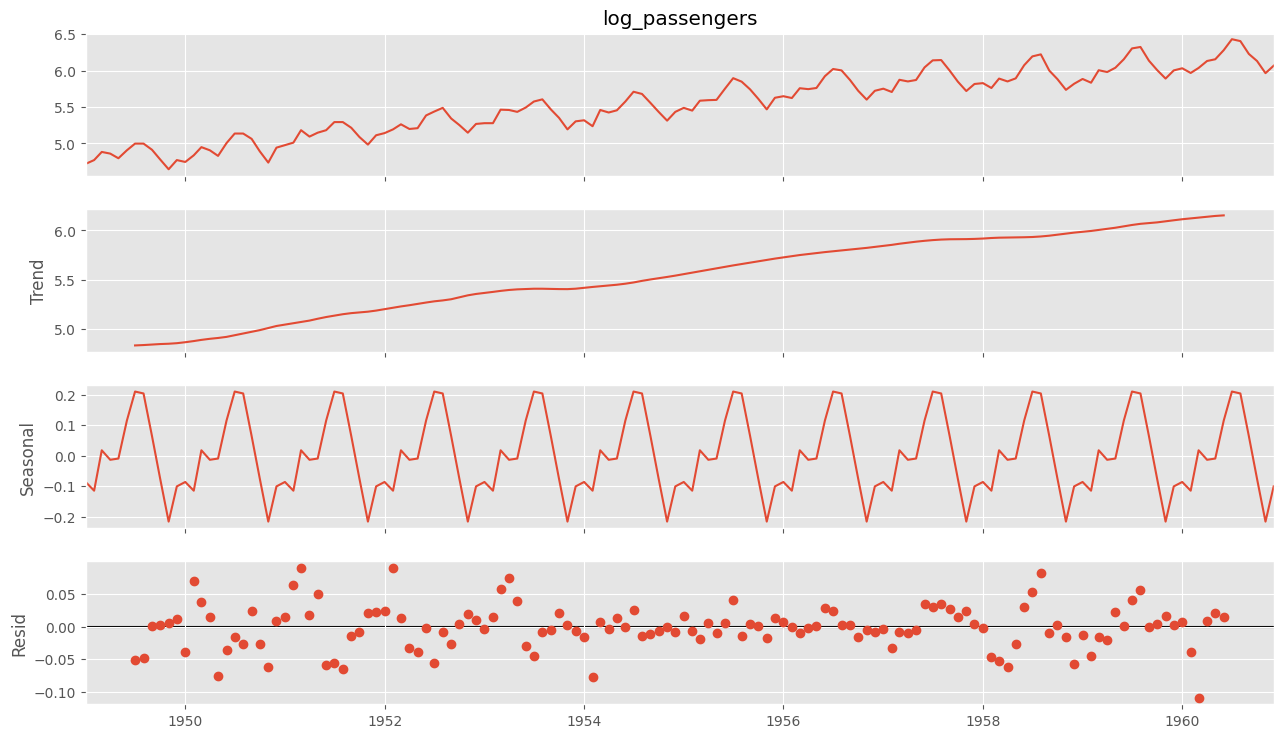

In [15]:
decomp = sead_(
    df["log_passengers"],
    model="additive",
    period=12
)

fig = decomp.plot()

fig.set_size_inches(14, 8)

plt.show()

<details><summary><strong>1. The top panel.</strong></summary>

It is the observed transformed time series. It is basically the same graph you just saw before decomposition.



```
    It contains everything mixed together: Observed  =  Trend  +  Seasonal  +  Residual.
```



 (model="additive" -> +, not *)
    
  Think of it as hearing an orchestra where all instruments are playing together.
  
  Decomposition attempts to separate the instruments.


</details>

<details><summary><strong>2.  Second panel: Trend</strong></summary>

- This tries to capture the long-term movement of passenger demand after removing short-term seasonality.

- The annual ups and downs have been filtered out.

- The trend ignores those short-term changes and asks:
    - “Ignoring recurring seasonal effects, what is happening to the underlying passenger level?”
    - Answer: It is generally increasing.



```
Seasonality answers “what usually happens within a year?”
Trend answers “what is changing across years?"
```

</details>

<details><summary><strong>3. Third panel: Seasonal</strong></summary>


- You see the same shape `repeating` every 12 months. That is the estimated seasonal effect.

- Notice the vertical scale: about `-0.2 to +0.2`. Because you're working on the log scale, those numbers are not passenger counts.

    - They represent deviations from the trend on the log scale.


```
Around the summer months you see a positive seasonal effect.
That means:
  - Passenger demand tends to be above its underlying trend during those months.

During low-season months you see a negative effect:
  - Passenger demand tends to be below its underlying trend.
```

Why does the seasonal component repeat exactly?
  > Because classical seasonal decomposition estimates one average seasonal pattern and repeats it.

Across the full seasonal cycle, positive and negative effects roughly balance.

- So zero means: No seasonal upward or downward effect relative to trend.

- Positive seasonal value: above the expected trend level.

- Negative seasonal value: below the expected trend level.

</details>

<details><summary><strong>4. Fourth panel: Resid - This means residual.</strong></summary>

Residual is:
$$ R_t = Y_t-T_t-S_t $$

So after we remove the estimated trend and estimated seasonality, residual is whatever remains.


“We explained the long-term growth. We explained the yearly recurring pattern. Now what is left?”


> Residual variation.

Ideally, residuals should look like random points fluctuating around zero.


The plot emphasizes each time point.


Around: 0; means: the trend + seasonal components explained that observation reasonably well.

Large positive residual: actual demand was higher than expected.

Large negative residual: actual demand was lower than expected.

For example, you have some residuals around: +0.08 and one around: -0.10
  
  - Those are months where the observed passenger demand deviated noticeably from what trend + seasonality predicted.


</details>

<details><summary><strong>What should a “good” residual plot look like?</strong></summary>

Ideally:
- centered around zero,
- no clear trend,
- no obvious recurring seasonality,
- approximately constant variation,
- no obvious systematic structure.

Why? Because if the residuals still contain an obvious pattern, that means:

> There is information we have not modeled yet.

For example, suppose your residual plot still showed:
- high every July
- low every November
Then your seasonal decomposition had failed to remove all seasonality.

Or suppose residuals systematically became positive after 1958.
- That could suggest a structural change.



So a reasonable interpretation is:
>>> The trend and seasonal components explain much of the systematic structure of the log-transformed passenger series, while the remaining residual variation is relatively small and centered around zero.

</details>

<details><summary><strong>Insights:</strong></summary>

- Observed: The log-transformed passenger series still shows long-term growth and a clear recurring annual pattern.

- Trend: The underlying passenger level increases steadily across the observation period after short-term seasonal variation is removed.

- Seasonal: A strong 12-month pattern repeats consistently. Positive seasonal effects correspond to high-demand months, while negative effects correspond to low-demand months.

- Residual: Most remaining deviations fluctuate around zero and are much smaller than the original variation, suggesting that trend and seasonality explain a substantial part of the systematic structure.
Then add the teaching question:

We already know:

`raw time plot → trend → seasonality → multiplicative behavior → log transformation → decomposition.`



Understanding the past is not the same as predicting the future.


To forecast properly, we must now define exactly what we want to predict and what information would actually be available at the moment the prediction is made.

## [RQ4 — What exactly are we forecasting, and what information is available at the time of prediction?](#scrollTo=8012e65e)

`Suppose` we are standing at the end of **1959**.

At that point:

- passenger data through December 1959 are known,
- passenger values for January–December 1960 are still unknown,
- management wants a 12-month forecast for planning purposes.

The point that separates the **known past** from the **unknown future** is called the **forecast origin**.

A forecasting method should use only information that would actually be available at or before that point.

Before building a model, we therefore need to ask:

> Which pieces of information are genuinely available when the forecast is made, and which would accidentally use information from the future?

```text
1949 -------------------- 1959 | 1960
          observed              future
                              ^
                         forecast origin
```

> *Central forecasting rule:* Use only information that would be available at or before the forecast origin.



In [16]:
df.tail()

,passengers,year,month,month_name,log_passengers
date,,,,,
1960-08-01,606,1960,8,Aug,6.406880
1960-09-01,508,1960,9,Sep,6.230481
1960-10-01,461,1960,10,Oct,6.133398
1960-11-01,390,1960,11,Nov,5.966147
1960-12-01,432,1960,12,Dec,6.068426


<details>
<summary><strong>Leakage thought experiment</strong></summary>

Imagine we are standing at the end of <strong>1959</strong>.  


> <strong>Would this information actually be available when we make the forecast?</strong>

- December 1959 passenger demand —  Yes
- July 1960 actual passenger demand —  No
- Knowing that a future observation corresponds to July —  Yes
- Historical average passenger demand for July —  Yes
- Total passenger demand for all of 1960 —  No

The important distinction is between information that is <strong>known at forecast time</strong> and information that becomes known only later.

>   Key idea: A value can appear in the dataset but still be unavailable at the time of prediction. - Do not use future information to predict the future.

Using future information to build or evaluate a model is called <strong>data leakage</strong>.

</details>

Now that we know what information is allowed at t`he forecast origin`, we can evaluate a model fairly by pretending the future is still unknown.

## [RQ5 — How should we evaluate a forecast honestly?](#scrollTo=8012e65e)



We simulate the real decision:

- **Training:** January 1949 – December 1959
- **Validation:** January 1960 – December 1960

Question:

> If we had stood at the end of 1959, how well would each method have forecast 1960?

In [17]:
df.head(2)

,passengers,year,month,month_name,log_passengers
date,,,,,
1949-01-01,112,1949,1,Jan,4.718499
1949-02-01,118,1949,2,Feb,4.770685


In [18]:
train = df.loc[:"1959-12-01"].copy()

valid = df.loc["1960-01-01":].copy()

In [19]:
train.tail(2)

,passengers,year,month,month_name,log_passengers
date,,,,,
1959-11-01,362,1959,11,Nov,5.891644
1959-12-01,405,1959,12,Dec,6.003887


In [20]:
valid.head(2)

,passengers,year,month,month_name,log_passengers
date,,,,,
1960-01-01,417,1960,1,Jan,6.033086
1960-02-01,391,1960,2,Feb,5.968708


In [21]:
print("Training:\t",
      train.index.min().date(), "to",
      train.index.max().date(),
      "n=", len(train)
      )


print("Validation:\t",
      valid.index.min().date(), "to",
      valid.index.max().date(),
      "n=", len(valid)
      )

Training:	 1949-01-01 to 1959-12-01 n= 132
Validation:	 1960-01-01 to 1960-12-01 n= 12


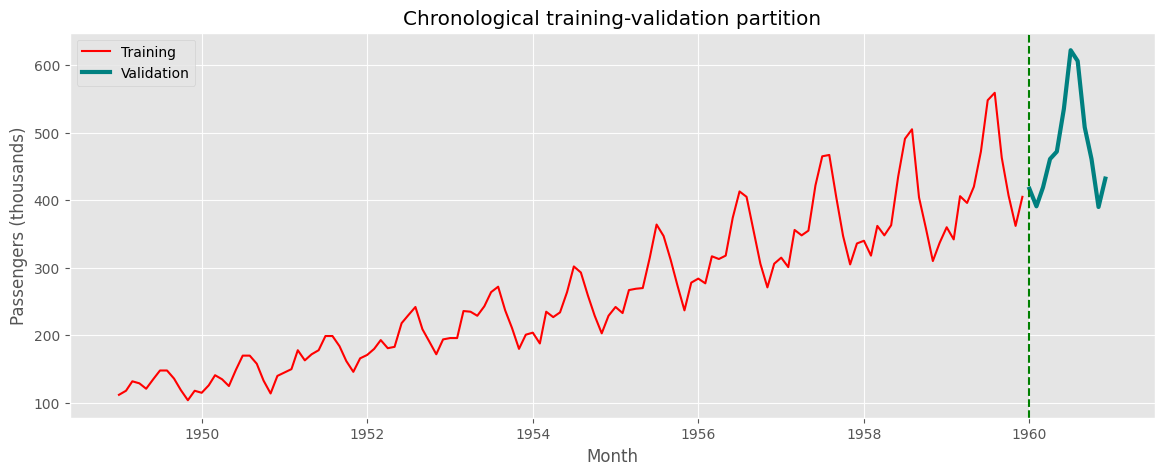

In [22]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(train.index,
        train["passengers"],
        label="Training",
        color = 'red'
        )

ax.plot(valid.index,
        valid["passengers"],
        label="Validation",
        linewidth=3,
        color = 'teal'
        )

ax.axvline(valid.index.min(), linestyle="--", color='green')

ax.set_title("Chronological training-validation partition")
ax.set_ylabel("Passengers (thousands)")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.95)
plt.show()

<details><summary><strong>Why not randomly place 20% of months into validation? (random split)</strong></summary>


Expected ideas:

- forecasting goes forward in time,
- later observations could enter training,
- temporal dependence is disrupted,
- the experiment would not resemble deployment.

Nuance:

> Random splitting is not universally “wrong”;
> it is usually wrong **for the forecasting question we are trying to answer**.

</details>

<details><summary><strong>Insights</strong></summary>

1. Training uses only observations available before 1960.
2. Validation uses the future period, 1960, to simulate real forecasting.
3. The 12-month validation window covers one full seasonal cycle.
4. Performance on validation data is more informative for forecasting than fit on training data.
5. Random splitting would break the time order and would not realistically simulate deployment.

</details>

## [RQ5B — How will we measure forecast quality?](#scrollTo=8012e65e)

1. **MAE** — typical absolute error in original units.
2. **RMSE** — penalizes large errors more strongly.
3. **MAPE** — expresses error in percentage terms, but is problematic near zero.

<details><summary><strong>1. Mean Absolute Error (MAE) </strong></summary>


It measures the average absolute difference between the actual values and the forecasts.

$$
MAE=\frac{1}{n}\sum_{t=1}^{n}|y_t-\hat y_t|
$$

Interpretation:

> “On average, how many thousand passengers are we off by?”

Strength:

* easy to explain,
* same units as the target.

Weakness:

* does not emphasize very large errors as strongly as RMSE.


</details>

<details><summary><strong> 2. Root Mean Squared Error (RMSE) </strong></summary>


It measures forecast error like MAE, but it gives **more weight to large mistakes**.




$$\mathrm{RMSE}=\left[\frac{1}{n}\sum\limits_{t=1}^{n}(y_t-\hat{y}_t)^2\right]^{1/2}$$




> RMSE = 27.4 means the forecast error is about 27.4 thousand passengers, with larger errors penalized more strongly than in MAE.

The key contrast is:

* **MAE** treats all absolute errors linearly.
* **RMSE** punishes large errors more.

That is why RMSE is useful when a few very large forecast misses are especially costly.
</details>

<details><summary><strong>3. Mean Absolute Percentage Error (MAPE)</strong></summary>


It measures the average size of the forecast error as a **percentage of the actual value**.

$$
MAPE=
\frac{100}{n}
\sum_{t=1}^{n}
\left|
\frac{y_t-\hat{y}_t}{y_t}
\right|
$$



### Simple example

Suppose:

```text
Actual = 500
Forecast = 450
```

Then the absolute error is:

$$
|500-450|=50
$$

Percentage error:

$$
\frac{50}{500}\times100=10\%
$$

So for that month, the absolute percentage error is **10%**.

If you calculate that percentage for every month and then average them, you get MAPE.

### Interpretation

If:

$$
MAPE=8\%
$$

you can say:

> **On average, the forecast differs from the actual value by about 8%.**

That is why managers often like MAPE—it is very intuitive.

### Strength

* Easy to explain
* Scale-independent
* Useful for comparing forecast accuracy across series with different units

### Weakness

MAPE becomes problematic when actual values are **zero or very close to zero**, because you divide by $y_t$.



> MAE tells us how many passengers we are off by.

> RMSE emphasizes large misses.

> MAPE tells us approximately what percentage we are off by.



</details>

In [23]:
from sklearn.metrics import mean_absolute_percentage_error as mape_

In [24]:
def evaluate(y_true, y_pred):
    mae = mae_(y_true, y_pred)
    rmse = np.sqrt(mse_(y_true, y_pred))
    mape_pct = mape_(y_true, y_pred) * 100

    #print(f"{'MAE':<7}: {mae:>7.2f}")
    #print(f"{'RMSE':<7}: {rmse:>7.2f}")
    #print(f"{'MAPE_%':<7}: {mape_pct:>7.2f}")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape_pct
    }

In [25]:
last_observed = train["passengers"].iloc[-1]
last_observed

np.int64(405)

In [26]:
naive_pred = np.repeat(
    last_observed,
    len(valid)
)
naive_pred

array([405, 405, 405, 405, 405, 405, 405, 405, 405, 405, 405, 405])

In [27]:
naive_scores = evaluate(valid["passengers"], naive_pred)
naive_scores

{'MAE': 76.0,
 'RMSE': np.float64(102.97653454387881),
 'MAPE_%': 14.251338486772209}

In [28]:
naive_scores['MAPE_%']

14.251338486772209

Forecast accuracy should not be judged from a single metric only.   Each metric emphasizes a different aspect of forecast error.






<details><summary><strong>MAE — Mean Absolute Error</strong></summary>

- Use it when an error measure that is easy to interpret in the **original units of the target variable**.

For this dataset, passenger demand is measured in **thousands of passengers**.

So if:

$$
MAE = 76
$$

we can interpret it as:

> On average, the forecast is off by about **76,000 passengers per month**.

**MAE is especially useful when:**

- all forecast errors are considered roughly equally important,
- you want a metric that is easy to explain to managers,
- you want the error expressed in the same units as the target,
- very large errors should not dominate the metric too strongly.

**Example business question:**

> "On a typical month, approximately how many passengers are we off by?"



</details>

<details>
<summary><strong>RMSE — Root Mean Squared Error</strong></summary>

RMSE measures the typical size of the forecast errors, but it gives <strong>extra importance to large mistakes</strong>.

The idea is simple:

1. Calculate each forecast error.
2. Square the errors.
3. Average the squared errors.
4. Take the square root.

Because the errors are squared, large mistakes have much more influence.

For example:

- an error of 10 contributes $10^2 = 100$,
- an error of 40 contributes $40^2 = 1600$.

So an error four times larger contributes <strong>16 times more</strong> before the final square root is taken.

<strong>How do we interpret RMSE?</strong>

RMSE is expressed in the <strong>same units as the original variable</strong>.

For example, if passenger demand is measured in thousands and:

$$
RMSE = 103
$$

then the model has an RMSE of approximately <strong>103 thousand passengers</strong>.

>> RMSE of 103 means the forecast errors are typically around 103,000 passengers, especially `emphasizing the larger mistakes`.

This does not mean that every forecast is wrong by exactly 103 thousand passengers. Instead, it summarizes the overall size of the errors while placing greater emphasis on the larger mistakes.

<strong>RMSE is especially useful when:</strong>

- large forecasting errors have serious consequences,
- large underestimates or overestimates are costly,
- we want to penalize extreme mistakes more strongly,
- avoiding a few very bad forecasts is important.

<strong>Business question:</strong>

> Which model is less likely to make very large forecasting mistakes?

For an airline, a large forecasting error could mean too many empty seats or insufficient capacity during periods of high demand. RMSE is therefore useful when large planning mistakes are especially costly.

<strong>Key idea:</strong>

> Lower RMSE is better. RMSE pays more attention to large errors than MAE does.

</details>

<details>
<summary><strong>MAPE — Mean Absolute Percentage Error</strong></summary>

MAPE expresses forecast error as a <strong>percentage of the actual value</strong>.

$$
MAPE = 14.3\%
$$

we can say:

> On average, the forecast differs from the actual passenger demand by about <strong>14.3%</strong>.

<strong>MAPE is especially useful when:</strong>

- managers prefer percentage-based interpretation,
- you want an error measure that is easy to communicate,
- you want to compare forecast accuracy across series with different scales,
- the actual values are positive and not close to zero,
- relative error is more meaningful than absolute error.

<strong>Business question:</strong>

> Approximately what percentage are our forecasts off by?

>>> Important caution:  MAPE can become unstable or misleading when actual values are zero or very close to zero, because the calculation divides by the actual value.

<strong>Key idea:</strong>

> Lower MAPE is better. A MAPE of 14.3% means the forecasts are off by about 14.3% on average.

</details>

<details><summary><strong>Which metric should we use?</strong></summary>



There is no universally best metric.

- Use **MAE** when interpretability in the original units is most important.
- Use **RMSE** when large errors deserve extra penalty.
- Use **MAPE** when percentage error is useful for communication or comparison.

In practice, it is usually better to examine **all three metrics together**, together with a plot of actual versus forecast values.

A model should not be selected simply because it has the lowest value on one metric.  
The choice should also reflect the **business consequences of forecast errors**.



</details>

<details><summary><strong>Insight</strong></summary>

- A naive forecast gives us our first benchmark.
- But this series clearly has seasonality.

</details>

#### Metrics summarize forecast quality, but plots diagnose forecast behavior.

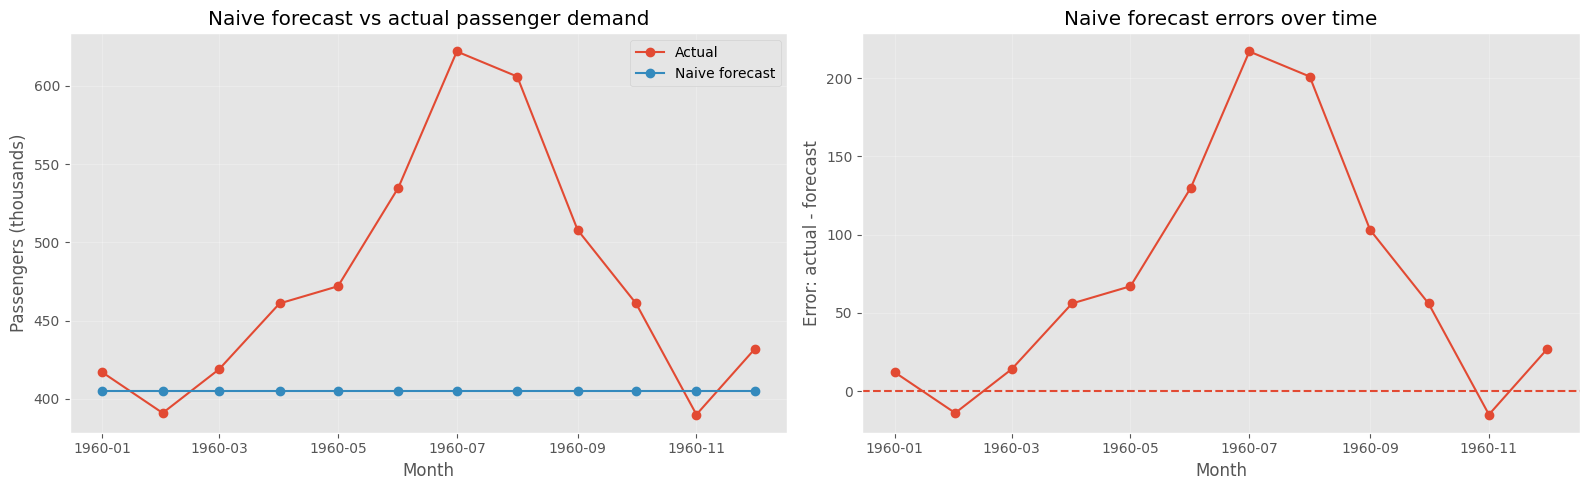

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Left: Forecast vs actual
# -----------------------------
axes[0].plot(
    valid.index,
    valid["passengers"],
    marker="o",
    label="Actual"
)

axes[0].plot(
    valid.index,
    naive_pred,
    marker="o",
    label="Naive forecast"
)

axes[0].set_title("Naive forecast vs actual passenger demand")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Passengers (thousands)")
axes[0].grid(alpha=0.25)
axes[0].legend()



# Right: Forecast errors
# -----------------------------
naive_error = valid["passengers"].values - naive_pred

axes[1].plot(
    valid.index,
    naive_error,
    marker="o"
)

axes[1].axhline(0, linestyle="--")

axes[1].set_title("Naive forecast errors over time")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Error: actual - forecast")
axes[1].grid(alpha=0.25)


plt.tight_layout()
plt.show()

<details><summary><strong>Insights from the naive forecast</strong></summary>


1. The naive method predicts the same value for every month of 1960: the last observed value from December 1959.

2. This ignores the strong seasonal pattern in passenger demand.

3. The largest errors occur during the summer peak, especially around July–August, because actual demand rises far above the flat naive forecast.

4. Because we define:  $\text{Error} = \text{Actual} - \text{Forecast}$ a *positive error* means the model is underforecasting, while a *negative error* means it is overforecasting.

5. The errors are not randomly scattered around zero. They follow a clear pattern over the year.

6. This tells us that the model is missing systematic information — specifically, seasonality.

> Key takeaway:  The naive forecast is a useful baseline, but it is too simple for this series because it ignores the repeating seasonal structure.


</details>


<details>
<summary><strong>Is one validation year always enough?</strong></summary>

Not necessarily.

Here we use one 12-month holdout because it matches management's forecasting horizon and keeps the experiment easy to understand.

In larger forecasting projects, we may evaluate the model at several forecast origins:

- train through 1957 → forecast 1958,
- train through 1958 → forecast 1959,
- train through 1959 → forecast 1960.

This is called **rolling-origin** or **time-series cross-validation**.

It provides evidence about whether performance is stable across different periods.

</details>

>>> Can we improve the benchmark by using the most recent value from the same month of the previous year?

## [RQ6 — Can a trivial forecast already perform well?](#scrollTo=8012e65e)


Before sophistication, establish a benchmark.




#### Naive forecast

Forecast every future month using the most recent observed value.

In [30]:
naive_scores

{'MAE': 76.0,
 'RMSE': np.float64(102.97653454387881),
 'MAPE_%': 14.251338486772209}

In [31]:
train.index[-36:] # choose last three years, prior to forecast

DatetimeIndex(['1957-01-01', '1957-02-01', '1957-03-01', '1957-04-01', '1957-05-01', '1957-06-01', '1957-07-01', '1957-08-01',
               '1957-09-01', '1957-10-01', '1957-11-01', '1957-12-01', '1958-01-01', '1958-02-01', '1958-03-01', '1958-04-01',
               '1958-05-01', '1958-06-01', '1958-07-01', '1958-08-01', '1958-09-01', '1958-10-01', '1958-11-01', '1958-12-01',
               '1959-01-01', '1959-02-01', '1959-03-01', '1959-04-01', '1959-05-01', '1959-06-01', '1959-07-01', '1959-08-01',
               '1959-09-01', '1959-10-01', '1959-11-01', '1959-12-01'],
              dtype='datetime64[ns]', name='date', freq=None)

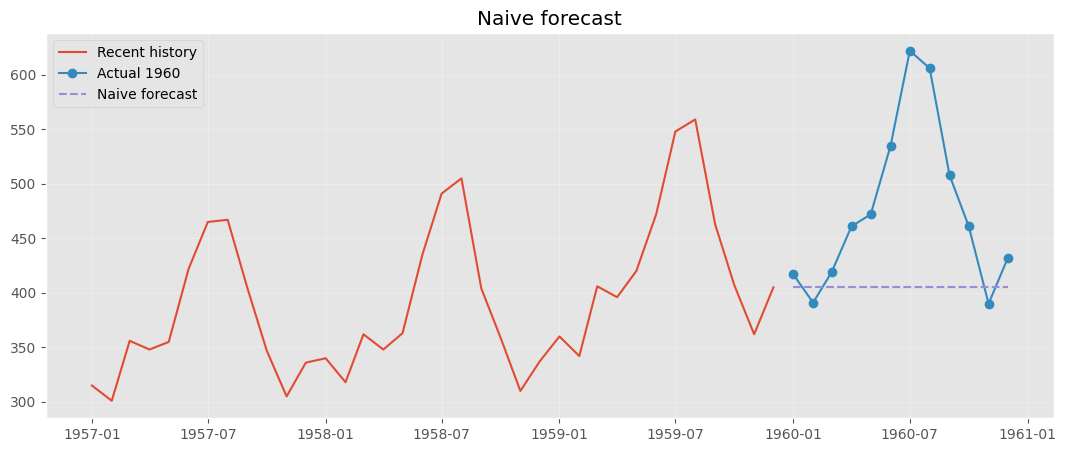

In [32]:
fig, ax = plt.subplots(figsize=(13,5))

ax.plot(train.index[-36:],  #-36 is purely a visualization choice, not a forecasting requirement.
        train["passengers"].iloc[-36:],
        label="Recent history"
        )

ax.plot(valid.index,
        valid["passengers"],
        marker="o",
        label="Actual 1960"
        )

ax.plot(valid.index,
        naive_pred,
        linestyle="--",
        label="Naive forecast"
        )

ax.set_title("Naive forecast")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

<details><summary><strong>Insights</strong></summary>



1. The naive forecast is completely flat.

2. The actual 1960 series still shows strong seasonality.

3. The naive forecast fails most badly during the summer peak.

4. The naive method ignores both seasonality and the upward long-term trend.

5. The historical plot makes the weakness obvious.



> If the same seasonal pattern repeats each year, can we create a smarter benchmark by using the passenger count from the same month one year earlier?


## [RQ7 — Does seasonality justify a stronger benchmark?](#scrollTo=8012e65e)



For monthly data with annual seasonality:

$$
\hat{y}_t = y_{t-12}
$$

This means:

- January 1960 uses January 1959,
- February 1960 uses February 1959,
- ...
- December 1960 uses December 1959.

This is called the **seasonal naive forecast**.

<details><summary><strong>Why seasonal naive? </strong></summary>

The ordinary naive forecast assumes that the most recent observation is the best estimate for every future month.

That can be reasonable when a series has little seasonal structure.

But our passenger series clearly shows a repeating annual cycle:

- summer months tend to be high,
- late autumn and winter months tend to be lower,
- and this pattern repeats year after year.

So a stronger benchmark is to ask:

> Instead of forecasting every future month using December 1959, why not forecast each month using the most recent observation from the same month one year earlier?
</details>


In [33]:
train.tail(13)

,passengers,year,month,month_name,log_passengers
date,,,,,
1958-12-01,337,1958,12,Dec,5.820083
1959-01-01,360,1959,1,Jan,5.886104
1959-02-01,342,1959,2,Feb,5.834811
1959-03-01,406,1959,3,Mar,6.006353
1959-04-01,396,1959,4,Apr,5.981414
1959-05-01,420,1959,5,May,6.040255
1959-06-01,472,1959,6,Jun,6.156979
1959-07-01,548,1959,7,Jul,6.306275
1959-08-01,559,1959,8,Aug,6.326149


In [34]:
seasonal_naive_pred = train["passengers"].iloc[-12:].to_numpy()
print(len(seasonal_naive_pred))
seasonal_naive_pred

12


array([360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405])

In [35]:
seasonal_naive_scores = evaluate(valid["passengers"],
                                 seasonal_naive_pred
                                 )
seasonal_naive_scores

{'MAE': 47.833333333333336,
 'RMSE': np.float64(50.708316214732804),
 'MAPE_%': 9.987532920823485}

In [36]:
benchmark_results = pd.DataFrame({
    "Naive": naive_scores,
    "Seasonal naive": seasonal_naive_scores
}).T
benchmark_results

,MAE,RMSE,MAPE_%
Naive,76.000000,102.976535,14.251338
Seasonal naive,47.833333,50.708316,9.987533


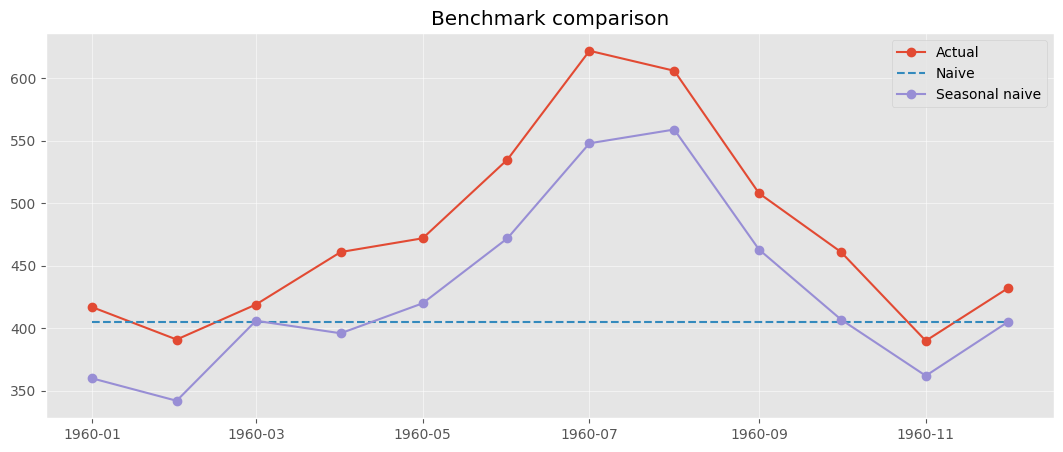

In [37]:
fig, ax = plt.subplots(figsize=(13,5))

ax.plot(valid.index,
        valid["passengers"],
        marker="o", label="Actual")

ax.plot(valid.index,
        naive_pred,
        linestyle="--", label="Naive")

ax.plot(valid.index,
        seasonal_naive_pred,
        marker="o", label="Seasonal naive")

ax.set_title("Benchmark comparison")
ax.legend()
ax.grid(alpha=0.5)
plt.show()

<details>
<summary><strong>Insights from the benchmark comparison</strong></summary>

1. The `ordinary naive` forecast is flat because it simply repeats the last observed value.

2. The `seasonal naive` forecast follows the yearly pattern much better because it reuses the values from the same months one year earlier.
  - However, seasonal naive still underforecasts much of 1960.

3. This tells us that seasonality is being captured, but the longer-term growth in passenger demand is not.

4. Seasonal naive is therefore a much stronger benchmark than ordinary naive, but it is still not a complete model.

</details>



1. What does seasonal naive capture correctly?

  - The repeating seasonal pattern.

2. What is it still missing?

  - The upward trend or growth in passenger demand.

3. Did seasonal naive “learn” a model?

  - Not in the machine-learning sense. It simply uses the assumption that seasonal patterns repeat from one year to the next.

4. What should we try next?

Can we build a model that captures both **trend** and **seasonality** at the same time?



> Key lesson: A more complex model is only useful if it performs better than a strong simple benchmark.


> > > Complexity has to earn its place.




## [RQ8 — Can trend + seasonal regression improve the forecast?](#scrollTo=8012e65e)



The seasonal-naive benchmark improved substantially because it respected the annual seasonal pattern.


This suggests that a stronger model should try to represent **both**:

1. the long-term trend, and
2. the repeating seasonal pattern.

A simple regression model can do exactly that.

We model passenger demand using:

- a **time trend**, to represent long-term growth;
- **month-of-year indicator variables**, to represent recurring seasonal differences between months.

Conceptually:

$$
\text{Demand}_t
=
\text{Trend effect}
+
\text{Seasonal effect}
+
\text{Error}_t
$$

More explicitly:

$$
y_t
=
\beta_0
+
\beta_1 t %%January is the omitted reference category.
+
\beta_2 D_{Feb}
+
\beta_3 D_{Mar}
+\cdots+
\beta_{12} D_{Dec}
+
\varepsilon_t
$$

where:

- $t$ is the time index,
- the month indicators represent seasonality,
- one month is omitted as the reference category,
- $\varepsilon_t$ represents unexplained variation.

Now, lets create the trend variable and the monthly dummy variables that the regression needs.

In [38]:
reg_df = df.copy()
reg_df["trend"] = np.arange(1, len(reg_df)+1)

month_dummies = pd.get_dummies(reg_df.index.month,
                               prefix="month",
                               drop_first=True,
                               dtype=float)
month_dummies

,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
139,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [39]:
month_dummies.index = reg_df.index
month_dummies

,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,
1949-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-02-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-03-01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-04-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-05-01,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1960-08-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1960-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1960-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [40]:
reg_df = pd.concat(
    [reg_df, month_dummies],
    axis=1
    )
reg_df

,passengers,year,month,month_name,log_passengers,trend,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,
1949-01-01,112,1949,1,Jan,4.718499,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-02-01,118,1949,2,Feb,4.770685,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-03-01,132,1949,3,Mar,4.882802,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-04-01,129,1949,4,Apr,4.859812,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-05-01,121,1949,5,May,4.795791,5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960-08-01,606,1960,8,Aug,6.406880,140,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1960-09-01,508,1960,9,Sep,6.230481,141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1960-10-01,461,1960,10,Oct,6.133398,142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [41]:
train.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01', '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1959-03-01', '1959-04-01', '1959-05-01', '1959-06-01', '1959-07-01', '1959-08-01', '1959-09-01', '1959-10-01',
               '1959-11-01', '1959-12-01'],
              dtype='datetime64[ns]', name='date', length=132, freq=None)

In [42]:
reg_train = reg_df.loc[train.index]
reg_valid = reg_df.loc[valid.index]

feature_cols = ["trend"] + list(month_dummies.columns)
feature_cols

['trend',
 'month_2',
 'month_3',
 'month_4',
 'month_5',
 'month_6',
 'month_7',
 'month_8',
 'month_9',
 'month_10',
 'month_11',
 'month_12']

In [43]:
X_train = reg_train[feature_cols]
y_train = reg_train["passengers"]

print(X_train)
print('___'*40)
print(y_train)

            trend  month_2  month_3  month_4  month_5  month_6  month_7  month_8  month_9  month_10  month_11  month_12
date                                                                                                                   
1949-01-01      1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1949-02-01      2      1.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1949-03-01      3      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1949-04-01      4      0.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1949-05-01      5      0.0      0.0      0.0      1.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
...           ...      ...      ...      ...      ...      ...      ...      ...      ...       ...       ...       ...
1959-08-01    128      0.0      0.0     

In [44]:
X_valid = reg_valid[feature_cols]
y_valid = reg_valid["passengers"]

print(X_valid)
print('___'*40)
print(y_valid)

            trend  month_2  month_3  month_4  month_5  month_6  month_7  month_8  month_9  month_10  month_11  month_12
date                                                                                                                   
1960-01-01    133      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1960-02-01    134      1.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1960-03-01    135      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1960-04-01    136      0.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1960-05-01    137      0.0      0.0      0.0      1.0      0.0      0.0      0.0      0.0       0.0       0.0       0.0
1960-06-01    138      0.0      0.0      0.0      0.0      1.0      0.0      0.0      0.0       0.0       0.0       0.0
1960-07-01    139      0.0      0.0     

In [45]:
linear_model = LinearRegression().fit(X_train, y_train)
reg_pred = linear_model.predict(X_valid)
reg_pred

array([410.72272727, 405.72272727, 441.54090909, 434.35909091,
       438.54090909, 476.26818182, 511.63181818, 512.81363636,
       468.63181818, 433.81363636, 403.45      , 431.26818182])

In [46]:
reg_scores = evaluate(y_valid, reg_pred)
reg_scores

{'MAE': 37.22196969696963,
 'RMSE': np.float64(49.479082106640725),
 'MAPE_%': 7.073538805164905}

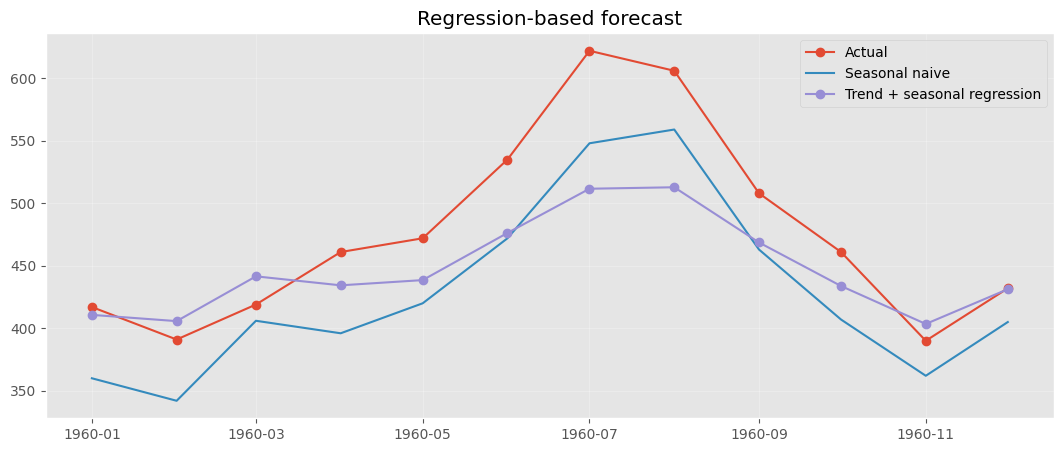

In [47]:
fig, ax = plt.subplots(figsize=(13,5))

ax.plot(valid.index,
        valid["passengers"],
        marker="o", label="Actual")

ax.plot(valid.index,
        seasonal_naive_pred,
        label="Seasonal naive")

ax.plot(valid.index,
        reg_pred,
        marker="o", label="Trend + seasonal regression")

ax.set_title("Regression-based forecast")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

<details><summary><strong>Insights</strong></summary>



1. The error metrics drop to approximately:

    - MAE = 37.22

    - RMSE = 49.48

    - MAPE = 7.07%

   Compared with the naive forecast, this is a large improvement.

2. Seasonal naive captured the yearly pattern well, but it tended to stay too low because it simply reused 1959 values.


3. The regression captures both major structures we identified earlier:

   - long-term growth,

   - recurring month-of-year seasonality.

4. The model still underestimates the summer peak.
   This suggests the simple additive regression does not fully capture how seasonal amplitude grows with the overall passenger level.

5. The remaining errors are structured, not purely random.
   The largest misses are concentrated near the seasonal peak. That is a clue that the additive specification may still be too simple.

This is exactly where the earlier log-transformation discussion becomes useful again.

</details>

> The regression improves substantially by modeling both trend and seasonality. However, it still underestimates the highest-demand months. Earlier we observed that seasonal fluctuations increase as passenger demand grows.

> Could modeling **log(passengers)** instead of passengers directly better represent this multiplicative behavior?

That leads naturally into the **log trend + seasonal regression** model.


## [RQ8 B —  Regression on the log scale](#scrollTo=8012e65e)

Because seasonal amplitude grows with level, fit the same structure to `log(passengers)` and transform predictions back.

In [48]:
X_train

,trend,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,
1949-01-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-02-01,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-03-01,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-04-01,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1949-05-01,5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1959-08-01,128,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1959-09-01,129,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1959-10-01,130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [49]:
y_train

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1959-08-01,559
1959-09-01,463
1959-10-01,407


In [50]:
log_y_train = np.log(y_train)
log_y_train

,passengers
date,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1959-08-01,6.326149
1959-09-01,6.137727
1959-10-01,6.008813


In [51]:
log_model = LinearRegression().fit(X_train, log_y_train)

log_pred = np.exp(log_model.predict(X_valid))

log_pred

array([439.7031365 , 436.53858095, 505.54612589, 489.71699919,
       492.78834648, 562.80010914, 628.66763973, 630.6910667 ,
       553.38464978, 485.48343232, 426.04757581, 483.21102   ])

In [52]:
log_reg_scores = evaluate(y_valid, log_pred)

log_reg_scores

{'MAE': 35.04822354009428,
 'RMSE': np.float64(40.15013647429604),
 'MAPE_%': 7.83875566698301}

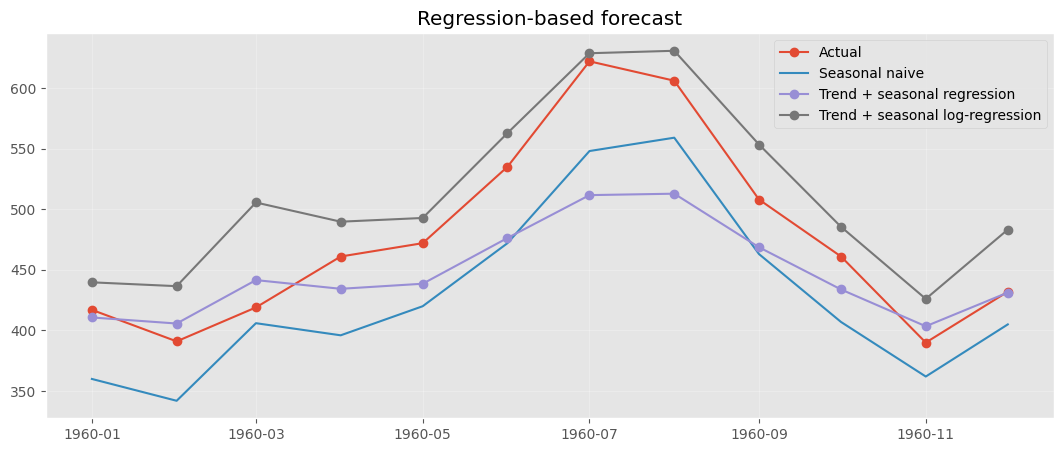

In [53]:
fig, ax = plt.subplots(figsize=(13,5))

ax.plot(valid.index,
        valid["passengers"],
        marker="o", label="Actual")

ax.plot(valid.index,
        seasonal_naive_pred,
        label="Seasonal naive")

ax.plot(valid.index,
        reg_pred,
        marker="o", label="Trend + seasonal regression")

ax.plot(valid.index,
        log_pred,
        marker="o", label="Trend + seasonal log-regression")

ax.set_title("Regression-based forecast")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

<details><summary><strong>Insights</strong></summary>


  - MAE drops from **37.22 → 35.05**, and RMSE from **49.48 → 40.15**.

  - It captures the **summer peak better**, which is consistent with the earlier evidence of multiplicative seasonality.

  - MAPE is slightly worse: 7.84% vs 7.07% for the ordinary regression.

  - So the log model is better for reducing large misses, while the ordinary regression is slightly better in relative percentage error.

> No single metric gives the whole story.


</details>

The log transformation helps the model represent increasing seasonal amplitude, but it still requires us to specify the trend and seasonal structure explicitly.

Can a smoothing method adapt to level, trend, and seasonality more automatically?

## [RQ9 — Can an adaptive smoothing model do better?](#scrollTo=8012e65e)


### Why `Holt–Winters`?

So far:

- the naive forecast ignored trend and seasonality,
- seasonal naive captured seasonality but not growth,
- regression explicitly modeled trend and month effects.

`Holt–Winters` takes a different approach.

Instead of fitting one fixed regression equation, it continuously updates three components over time:

- **Level** — the current baseline of the series,
- **Trend** — the current direction of growth,
- **Seasonality** — the repeating monthly pattern.

Because the seasonal swings become larger as passenger demand increases, we use **multiplicative seasonality**.

### Holt–Winters in equations

For monthly demand with additive trend and multiplicative seasonality:


\begin{align*}
\ell_t &= \alpha \frac{y_t}{s_{t-m}}
+ (1-\alpha)(\ell_{t-1}+b_{t-1}) \\
b_t &= \beta(\ell_t-\ell_{t-1})
+ (1-\beta)b_{t-1} \\
s_t &= \gamma \frac{y_t}{\ell_t}
+ (1-\gamma)s_{t-m}
\end{align*}


The $h$-step-ahead forecast is:

$$
\hat{y}_{t+h} = (\ell_t + hb_t)s_{t-m+h}
$$

where:

- $\ell_t$: level
- $b_t$: trend
- $s_t$: seasonal factor
- $m=12$: monthly seasonal period
- $\alpha,\beta,\gamma$: smoothing parameters learned from the data

### What do we learn?

- Holt–Winters improves substantially over seasonal naive because it updates both the underlying level and the trend.

- Notice that the seasonal naive forecast reproduces last year's shape almost exactly, while Holt–Winters raises the seasonal pattern to reflect the higher current demand level.

This is precisely why multiplicative seasonality is useful here: seasonal fluctuations grow as the series grows.

| Method | Level | Trend | Seasonality | Main idea |
|---|---:|---:|---:|---|
| Simple Exponential Smoothing | ✓ | — | — | Smooths the current level |
| Holt’s method | ✓ | ✓ | — | Adds a trend component |
| Damped Holt | ✓ | ✓ | — | Trend gradually weakens |
| Holt–Winters additive | ✓ | ✓ | ✓ | Constant seasonal amplitude |
| Holt–Winters multiplicative | ✓ | ✓ | ✓ | Seasonal amplitude grows with level |
| Error–Trend–Seasonality | depends | depends | depends | General exponential-smoothing framework |
| Seasonal naive | — | — | ✓ | Repeats last season; benchmark, not really a smoothing model |


There are also forecasting approaches outside exponential smoothing, including:

- Moving averages - smooth short-term fluctuations.
- ARIMA/SARIMA — model autocorrelation and, in SARIMA, seasonality.
- Dynamic regression — combines regression with time-series structure.
- State-space models — represent the evolution of unobserved components such as level and trend.
- Prophet — models trend, seasonality, holidays, and structural changes.
- TBATS — useful for complex or multiple seasonal patterns.
- Machine-learning models — such as Random Forest, XGBoost, and neural networks, often using lagged values and calendar variables as predictors.


#### From exponential smoothing to ETS:

| Component | Typical options |
|---|---|
| Error | Additive (A) or Multiplicative (M) |
| Trend | None (N), Additive (A), Damped additive (Ad) |
| Seasonality | None (N), Additive (A), Multiplicative (M) |

Exponential smoothing is a family of models.

- Simple Exponential Smoothing: level only
- Holt's method: level + trend
- Holt–Winters: level + trend + seasonality
- ETS: a general framework that systematically combines different forms of
  error, trend, and seasonality

For example:

**ETS(A,A,M)** = additive error + additive trend + multiplicative seasonality.

In [54]:
hw_model = exps_(
    train["passengers"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated"
).fit()

hw_pred = hw_model.forecast(len(valid))
hw_scores = evaluate(valid["passengers"], hw_pred)
hw_scores

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


{'MAE': 10.30314296278632,
 'RMSE': np.float64(15.81038040261183),
 'MAPE_%': 2.2074214313335156}

Why multiplicative rather than additive seasonality?
> Because the seasonal variation becomes larger as passenger demand increases. If seasonal swings remained approximately constant over time, additive seasonality would be more appropriate.

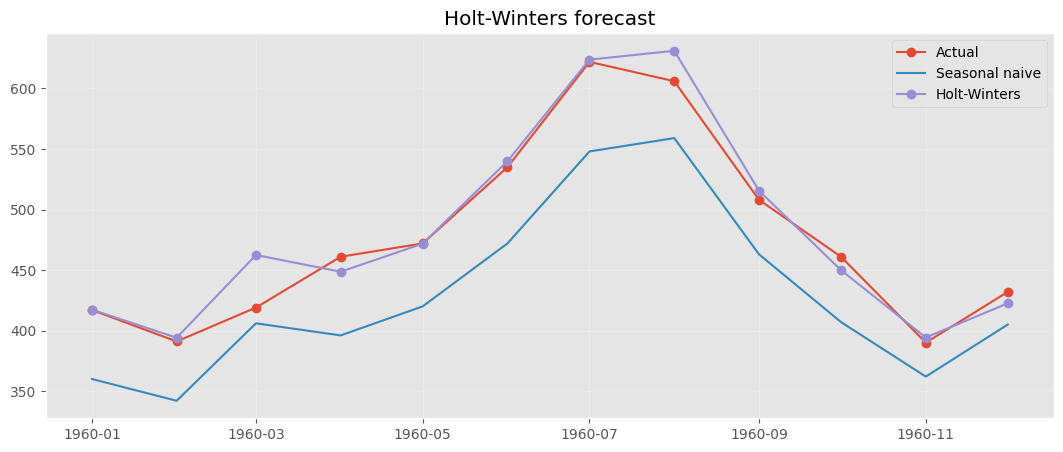

In [55]:
fig, ax = plt.subplots(figsize=(13,5))

ax.plot(valid.index,
        valid["passengers"],
        marker="o", label="Actual")

ax.plot(valid.index,
        seasonal_naive_pred,
        label="Seasonal naive")

ax.plot(valid.index,
        hw_pred,
        marker="o", label="Holt-Winters")

ax.set_title("Holt-Winters forecast")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

<details>
<summary><strong>Insights</strong></summary>

- Holt–Winters follows the actual demand much more closely than seasonal naive.
- Seasonal naive tends to underestimate demand because it does not adjust for the rising level.
- Holt–Winters captures both growth and seasonality, although some peaks are slightly overestimated.

#### Validation performance

- **MAE = 10.30**
- **RMSE = 15.81**
- **MAPE = 2.21%**

A MAPE of **2.21%** means the forecasts are, on average, about **2.2% away from the actual values**.

> Visual fit is useful, but model selection should be based mainly on **out-of-sample `validation performance`**.

</details>

#### From individual models to model selection

We have now tested several forecasting approaches on the same validation year.

The next question is no longer **“Does this model work?”** but:

> **Which model performs best on unseen data?**

To answer that fairly, every candidate must be compared using the **same validation period and the same error metrics**.

## [RQ10 — Which model would we recommend?](#scrollTo=8012e65e)

We compare all candidate models using the same validation year and the same metrics:

- **MAE**
- **RMSE**
- **MAPE**

The preferred model should show the strongest **out-of-sample performance**, not simply the best visual fit.

In [56]:
comparison = pd.DataFrame({
    "Naive": naive_scores,
    "Seasonal naive": seasonal_naive_scores,
    "Trend + season regression": reg_scores,
    "Log trend + season regression": log_reg_scores,
    "Holt-Winters": hw_scores
}).T.sort_values("MAE")
comparison

,MAE,RMSE,MAPE_%
Holt-Winters,10.303143,15.810380,2.207421
Log trend + season regression,35.048224,40.150136,7.838756
Trend + season regression,37.221970,49.479082,7.073539
Seasonal naive,47.833333,50.708316,9.987533
Naive,76.000000,102.976535,14.251338


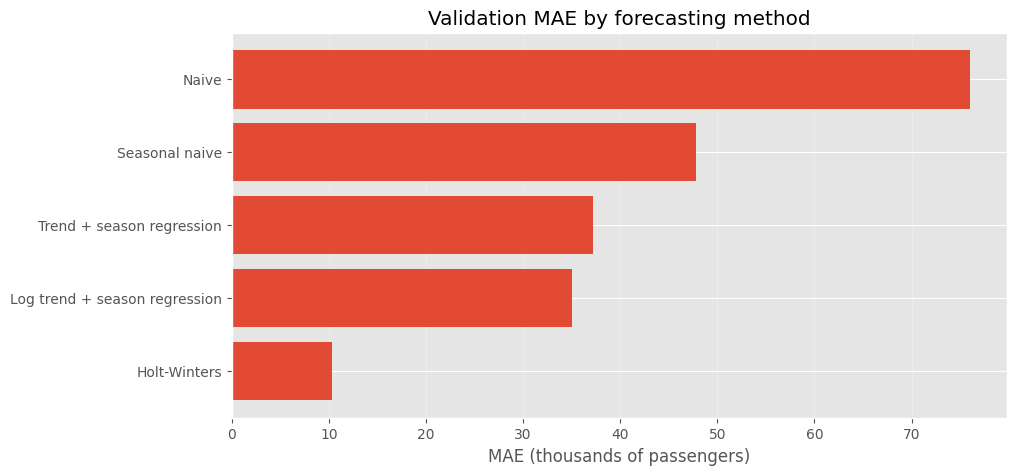

In [57]:
fig, ax = plt.subplots(figsize=(10,5))


ax.barh(comparison.index, comparison["MAE"])

ax.set_title("Validation MAE by forecasting method")
ax.set_xlabel("MAE (thousands of passengers)")
ax.grid(axis="x", alpha=0.25)
plt.show()

In [58]:
plot_df = (
    comparison
    .reset_index()
    .rename(columns={"index": "Model"})
    .melt(
        id_vars="Model",                         # Keep Model unchanged
        value_vars=["MAE", "RMSE", "MAPE_%"],    # Stack these columns
        var_name="Metric",                       # Store metric names here
        value_name="Value"                       # Store metric values here
    )
)

plot_df

,Model,Metric,Value
0,Holt-Winters,MAE,10.303143
1,Log trend + season regression,MAE,35.048224
2,Trend + season regression,MAE,37.221970
3,Seasonal naive,MAE,47.833333
4,Naive,MAE,76.000000
5,Holt-Winters,RMSE,15.810380
6,Log trend + season regression,RMSE,40.150136
7,Trend + season regression,RMSE,49.479082
8,Seasonal naive,RMSE,50.708316
9,Naive,RMSE,102.976535


In [59]:
import seaborn as sns

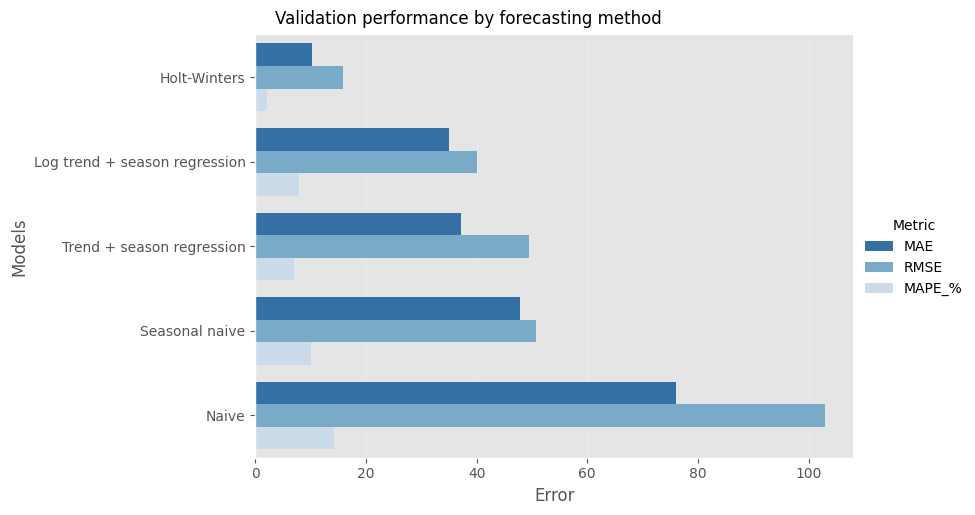

In [60]:
g = sns.catplot(
    data=plot_df,
    y="Model",
    x="Value",
    hue="Metric",
    kind="bar",
    palette="Blues_r",
    height=5,
    aspect=1.8
)

g.set_axis_labels("Error", "Models")
g.fig.suptitle(
    "Validation performance by forecasting method",
    y=1.02
)

for ax in g.axes.flat:
    ax.grid(axis="x", alpha=0.25)

plt.show()

**Note:** MAE and RMSE are measured in passengers, while MAPE is a percentage, so their bar lengths should not be compared directly across metrics.

<details>
<summary><strong>Insights</strong></summary>

- Holt–Winters has the lowest error across all three metrics: MAE, RMSE, and MAPE.
- Naive forecasting performs worst, showing that simply carrying the last value forward is inadequate for this series.
- Seasonal naive improves substantially, confirming that seasonality matters.
- Regression models improve further, but still do not match Holt–Winters.
- The consistent result across all metrics strengthens the case for Holt–Winters as the leading candidate.

> Model selection should not depend on one metric alone. Here, all three validation metrics point in the same direction.

### Model Selection Is More Than the Smallest Error

1. Which method is most accurate on the holdout?
2. Is the improvement meaningful?
3. Which model is easiest to explain?
4. Does it require unavailable future information?
5. Is it stable and maintainable?
6. Which method best matches the visible data structure?

### Decision moment

**Recommended method:**  

**Evidence:**  

**One limitation:**




<details>
<summary><strong>Model Selection Is More Than the Smallest Error</strong></summary>

The validation results show that **Holt–Winters has the lowest MAE, RMSE, and MAPE**.

But model selection should also consider whether the method is:

1. accurate on unseen data,
2. consistent with the structure of the series,
3. easy to explain,
4. usable without unavailable future information,
5. stable enough for repeated forecasting.

### Guided discussion

1. Which method is most accurate on the holdout?
Holt–Winters. It has the lowest MAE, RMSE, and MAPE.

2. Is the improvement meaningful?
Yes. Its errors are much smaller than those of the other candidate models.

3. Which model is easiest to explain?
Seasonal naive is simplest, but Holt–Winters is still interpretable because it explicitly updates level, trend, and seasonality.

4. Does it require unavailable future information?
No. Holt–Winters forecasts using patterns estimated from the historical series.

5. Is it stable and maintainable?
Yes. It can be re-estimated easily when new monthly observations become available.

6. Which method best matches the visible data structure?
Holt–Winters, because the series shows both trend and changing seasonal amplitude.

### Decision moment

Recommended method: Holt–Winters

Evidence: Lowest validation error across MAE, RMSE, and MAPE, while also matching the trend and seasonal structure of the data.

One limitation: The model assumes that the historical trend and seasonal pattern will remain informative in the future.

## [RQ10B — Did the model leave obvious structure unexplained?](#scrollTo=8012e65e)

i.e. Do residuals show an obvious pattern over time?

Residual:

$$
e_t = y_t - \hat{y}_t
$$

We inspect validation residuals for systematic bias or pattern.

In [61]:
# Combine actual and forecast
residual_df = pd.concat(
    [
        y_valid.rename("Actual"),
        hw_pred.rename("Predicted")
    ],
    axis=1
)

In [62]:
residual_df

,Actual,Predicted
1960-01-01,417,417.285292
1960-02-01,391,394.061710
1960-03-01,419,462.443977
1960-04-01,461,448.597682
1960-05-01,472,471.870014
1960-06-01,535,539.893479
1960-07-01,622,623.822882
1960-08-01,606,631.154011
1960-09-01,508,515.580412
1960-10-01,461,449.901749


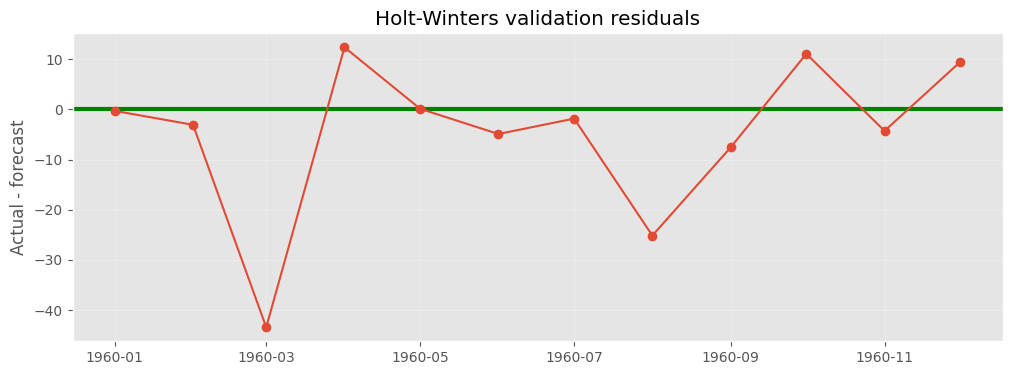

In [63]:
residuals = y_valid - np.asarray(hw_pred)

fig, ax = plt.subplots(figsize=(12,4))

ax.axhline(0, linewidth=3, color = 'green')

ax.plot(valid.index, residuals, marker="o")

ax.set_title("Holt-Winters validation residuals")
ax.set_ylabel("Actual - forecast")
ax.grid(alpha=0.25)
plt.show()

<details><summary><strong>What would concern us?</strong></summary>

- all residuals positive,
- all residuals negative,
- a remaining seasonal wave,
- error increasing strongly over time.

These indicate bias or missing structure.
</details>

<details><summary><strong>Insights</strong></summary>

  - Residuals fluctuate around zero, so there is **no obvious systematic over- or under-forecasting**.

  - Most errors are relatively small, which is consistent with the strong validation metrics.

  - The largest negative residual occurs around **March**, meaning Holt–Winters substantially **overpredicted** that month.

  - Another noticeable overprediction appears around **August**.

  - Positive residuals in months such as **April, October, and December** indicate some underprediction.

  - There is no clear trend or repeating seasonal pattern visible in the residuals.

</details>

### Conclusion

1. The residual plot does not show strong obvious structure left unexplained by the model.

2. This supports Holt–Winters as a reasonable forecasting model, although the few larger residuals suggest that some month-specific variation is not fully captured.

> A residual plot is only a first diagnostic. The next step is to check whether residuals are autocorrelated.

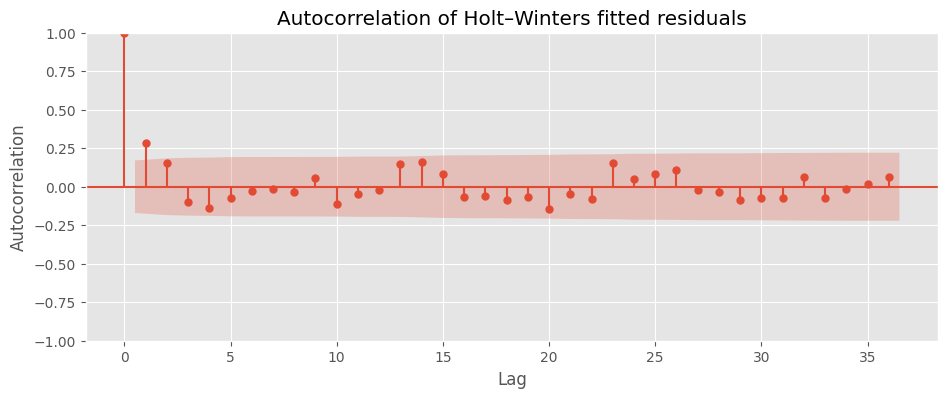

In [64]:
hw_resid = hw_model.resid

fig, ax = plt.subplots(figsize=(11,4))
plot_acf(hw_resid.dropna(), lags=36, ax=ax)

ax.set_title("Autocorrelation of Holt–Winters fitted residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.show()

## [RQ10C —  Are the residuals autocorrelated?](#scrollTo=8012e65e)

i.e. Even if `no pattern (10b)` is obvious visually, residuals may still be correlated with their own past values.

- **Autocorrelation** measures whether a series is related to its own past values.

- A residual plot can reveal obvious patterns, but some structure may be harder to see visually.



For lag $k$:

$$ \rho_k = Corr(y_t, y_{t-k}) $$

For model diagnostics, we are especially interested in the *residuals*:

$$
Corr(e_t, e_{t-k})
$$

If residual autocorrelation remains, then the model may have left predictable structure unexplained.

A good forecasting model should ideally leave residuals that behave approximately like *white noise*:

- centered around zero,
- no clear pattern,
- little or no autocorrelation.

We inspect this using the *autocorrelation function (ACF)*.


In that ACF plot:

- *X-axis = lag*
  - Lag 1 = correlation with *1 month earlier*
  - Lag 2 = correlation with *2 months earlier*
  - Lag 12 = correlation with *12 months earlier*


- *Y-axis = autocorrelation*
  - Values range from *-1 to 1*
  - Close to *1* = strong positive relationship
  - Close to *0* = little relationship
  - Close to *-1* = strong negative relationship

So for example, a bar near *0.75 at lag 12* means passenger demand is strongly positively related to demand *12 months earlier*.


And conceptually:

> “How similar is the series to itself $k$ months ago?”

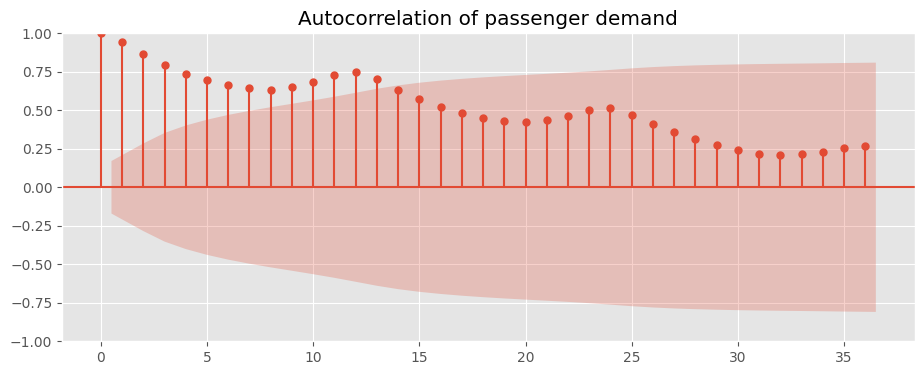

In [65]:
fig, ax = plt.subplots(figsize=(11,4))

plot_acf(train["passengers"], lags=36, ax=ax)

ax.set_title("Autocorrelation of passenger demand")
plt.show()

<details><summary>How to read this ACF</summary>

- Large bars at small lags → nearby months are strongly related.
  - (not bad by itself. It means nearby months are related. In a real time series, this is common and often useful for forecasting.)

- Slow decay → strong persistence/trend.
  - (That is informative, not inherently bad. But it also means the series is not behaving like independent random noise.)

- Peaks around lag 12 and 24 → yearly seasonality.
  - (actually useful: they reveal yearly seasonality. For monthly passenger data, that is expected structure a forecasting model should capture.)

- Many bars away from zero → the observations are not independent.
  - (Again, not bad; it confirms there is forecastable structure.)

**Note:** For RQ10C as a model-diagnostics section, use the residuals, not the training series.

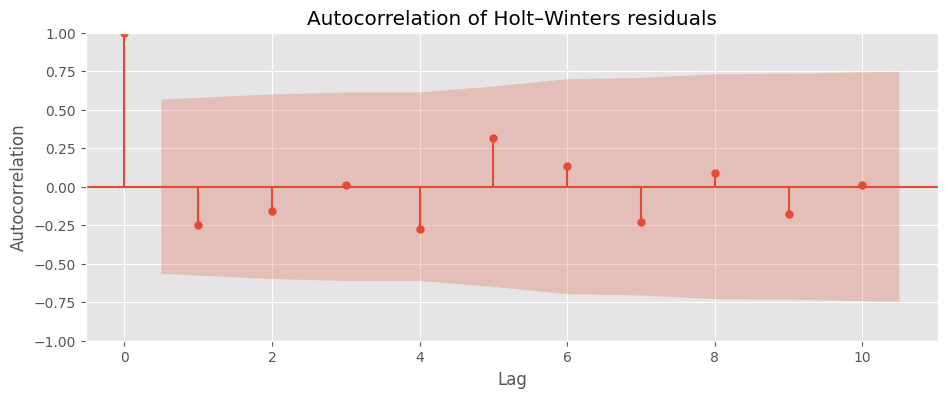

In [66]:
fig, ax = plt.subplots(figsize=(11,4))

plot_acf(residuals, lags=10, ax=ax)

ax.set_title("Autocorrelation of Holt–Winters residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.show()

<details>
<summary>At **lag 0**, the series is correlated with itself at the same time point: </summary>


$$
Corr(e_t, e_t) = 1
$$

So the autocorrelation is always exactly **1**.

That is why the first bar is fixed at 1 and is not interpreted like the others. The shaded confidence band is meant for **lags greater than 0**, where we are asking whether the residuals are correlated with past residuals.

So:

- lag 0 = correlation with itself → always 1
- lag 1 = correlation with 1 period earlier
- lag 2 = correlation with 2 periods earlier
- etc.



> **Ignore lag 0. It is always 1 by definition. We interpret lags 1 onward.**

<details>
<summary><strong>Insights</strong></summary>

- All residual autocorrelations are relatively small.
- All bars lie within the confidence band.
- There is no clear repeating pattern across lags.

This suggests that the residuals behave approximately like uncorrelated noise.

</details>

<details>
<summary><strong>Conclusion</strong></summary>

- Holt–Winters captured most of the time pattern in the data.
- The remaining forecast errors do not show a clear pattern or relationship with previous errors.

> After Holt–Winters makes its forecast, the leftover errors mostly look random. That is what we want from a good forecasting model.

</details>

**Caution:** The validation set contains only 12 observations, so the residual ACF is based on a very small sample and should be interpreted cautiously.

#### Final decision

The comparison and diagnostics point to the same conclusion:

- Holt–Winters has the lowest validation error.
- Its residuals show no obvious remaining pattern.
- Residual autocorrelation is small and stays within the confidence band.
- The method is therefore a reasonable choice for this series.

> We have finished **model selection**.  
> The next step is **model deployment**: refit the chosen method using all available data and forecast beyond the observed period.

## [RQ11 — We selected a method. How do we forecast the real future?](#scrollTo=8012e65e)

- Validation helped us choose a method.

- During validation, we deliberately held back the last 12 months so we could test the models fairly.

- Now that Holt–Winters has been selected, we no longer need to exclude those observations.

- We therefore refit the model using *all observed data* before forecasting the true future.

Now we should *refit using all observed data* before forecasting the actual future.

Why?

1. The latest observations are closest to the forecast period.
2. More data can improve estimation.
3. The validation set no longer needs to remain excluded after model selection.

In [67]:
final_model = exps_( #ExponentialSmoothing is just the Python class name. The specific options determine which member of the exponential-smoothing family you are using
    df["passengers"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated"
).fit() #Holt–Winters with additive trend and multiplicative monthly seasonality

final_model


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [68]:
future_pred = final_model.forecast(12)
future_pred

,0
1961-01-01,445.242404
1961-02-01,418.225356
1961-03-01,465.309718
1961-04-01,494.951214
1961-05-01,505.475856
1961-06-01,573.312593
1961-07-01,663.596298
1961-08-01,654.903946
1961-09-01,546.760961
1961-10-01,488.446893


In [69]:
future_dates = pd.date_range(df.index.max() + pd.offsets.MonthBegin(1),
                             periods=12,
                             freq="MS" #Month Start 1961-02-01, ...
                             )
future_dates

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01', '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [70]:
future_forecast = pd.Series(np.asarray(future_pred),
                            index=future_dates,
                            name="forecast"
                            )

future_forecast

,forecast
1961-01-01,445.242404
1961-02-01,418.225356
1961-03-01,465.309718
1961-04-01,494.951214
1961-05-01,505.475856
1961-06-01,573.312593
1961-07-01,663.596298
1961-08-01,654.903946
1961-09-01,546.760961
1961-10-01,488.446893


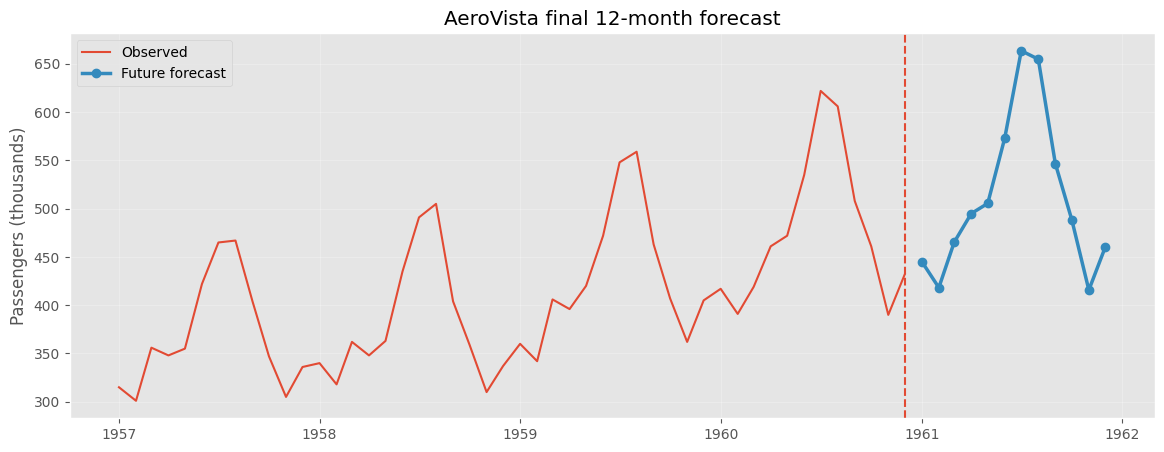

In [71]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(df.index[-48:],
        df["passengers"].iloc[-48:],
        label="Observed"
        )

ax.plot(future_forecast.index,
        future_forecast,
        marker="o", linewidth=2.5, label="Future forecast")

ax.axvline(df.index.max(), linestyle="--")

ax.set_title("AeroVista final 12-month forecast")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

We selected Holt–Winters using the validation experiment, then refit the same model using *all observed data*.


<details>
<summary><strong>Conclusion</strong></summary>

The final forecast preserves the two main features seen in the historical series:

- continued growth in the overall level,
- a strong repeating seasonal pattern.

</details>

> The model now gives us a forecast for the real future.  
  > But management should not receive only a single forecast line — they also need to understand the uncertainty, assumptions, and risks behind it.

## [RQ12 — What should management be told besides the forecast?](#scrollTo=8012e65e)




A production forecast should communicate more than one number.


<details>
<summary><strong>Prediction - What do we expect?</strong></summary>


State the expected demand pattern and the main forecast result.

</details>

Passenger demand is expected to continue growing, with the usual seasonal peak during the middle of the year.


<details>
<summary><strong>Accuracy evidence</strong></summary>

How well did the method perform on unseen historical data?

Use the validation results to show how reliable the method was.

- MAE = **10.30 thousand passengers**
- RMSE = **15.81 thousand passengers**
- MAPE = **2.21%**
</details>

> The model was, on average, about 2.2% away from the actual validation values.

<details>
<summary><strong>Assumptions</strong></summary>

What must remain reasonably stable?

</details>

The forecast assumes that:

- the historical growth pattern continues,
- the seasonal pattern remains similar,
- no major structural change occurs.

<details>
<summary><strong>Risks</strong></summary>

What could cause the forecast to fail?
</details>

- economic shocks,
- changes in travel demand,
- new competitors,
- capacity constraints,
- unusual events that are not represented in the historical data.



<details>
<summary><strong>Monitoring</strong></summary>

How will we know when the model needs updating?

Compare new actual observations with the forecast and monitor forecast error.
</details>

> If errors become consistently larger or show a systematic pattern, the model should be reviewed and refitted.



## Final thoughts

1. Why should time-series training and validation usually be split chronologically?  
2. What is the difference between naive and seasonal naive?  
3. Why is seasonal naive a particularly important benchmark here?  
4. What evidence suggested multiplicative seasonality?  
5. Why do we refit on the full historical series before forecasting the real future?  
6. Why might the lowest validation error still not be sufficient for choosing a production model?

### Common Misconceptions

1. Time series means ARIMA -  ARIMA is one model family. Forecasting starts with problem framing, structure, benchmarks and validation.

2. Random split is always best practice.

3. Seasonality means weather seasons.

4. Lower training error means a better forecasting model - Future-like validation performance matters more.

5. Sophisticated methods should beat simple methods - Not necessarily. Seasonal naive can be extremely competitive.

6. After validation, keep the validation period excluded forever. - No. Refit on all observed data after model selection.

7. Forecast equals truth -  A forecast is a conditional estimate under assumptions.

We answered a forecasting question by moving:
  - from business context to temporal structure,
  - from structure to benchmarks,
  - from benchmarks to models, and
  - from models to a decision.
  
  The most important skill was not fitting Holt-Winters or regression.
  

It was designing an honest experiment that respects time.

   - If the validation design is wrong, the model comparison is meaningless.

   - If the benchmark is weak, the improvement is meaningless.   
   
   - And if the forecast cannot be translated into a decision, the analysis is unfinished.

---